# Qualitative evidence — the text prior is redundant with the VPH features

Two figures for the presentation.

**Figure 1 — "the backbone already sees the text."**
Per image: the document, the **VPH feature energy** (‖feat‖₂ over the 96 channels of `F_v` level 0,
no training involved), the **text head's readout** of those same frozen features, the **external OCR
mask** `M_text`, and the **GT tamper mask**. If the VPH panel and the OCR panel show the same
structure, the prior is telling the network something it already encodes.

**Figure 2 — "and so the prior changes nothing."**
GT, the frozen-baseline prediction, the +prior prediction, and the **absolute difference** between
them. The difference map is the point: if it is near-black, the prior did not move the output.

Both figures print supporting numbers (IoU between the VPH readout and the OCR mask; mean and max
|Δ| between the two predictions) so the figures are not purely visual claims.

> Reuses the OCR cache from `final_results_colab.ipynb`, so OCR is fast if you have already run it.

## 0. Setup

Same setup as `final_results_colab.ipynb`. If that notebook is already running in this session, skip to section 1 — every symbol it defines is reused.

In [1]:
# --- CONFIG ---
from pathlib import Path

CONFIG = {
    'PROJECT_REPO_URL': 'https://github.com/SamiraAbedini/HLCV-Project.git',
    'PROJECT_BRANCH': 'main',
    'PROJECT_DIR': '/content/HLCV-Project',
    'DOCTAMPER_DIR': '/content/DocTamper',

    'CHECKPOINT_DIR': '/content/drive/MyDrive/HLCV/checkpoints',
    'FINAL_OUT':    '/content/drive/MyDrive/HLCV_samira/final_seed42',   # arms/ + ocr_cache/
    'TA_OUT':       '/content/drive/MyDrive/HLCV_samira/ta_design',      # ext_arms/ (text head)
    'OUT_ROOT':     '/content/drive/MyDrive/HLCV_samira/qualitative',
    'MANIFEST_DIR': '/content/drive/MyDrive/HLCV_samira/manifests/train800_val200_test200_seed42',

    'DRIVE_ZIP': '/content/drive/MyDrive/HLCV_samira/data/doctamper.zip',
    'KAGGLE_DATASET': 'dinmkeljiame/doctamper',
    'DATA_ROOT': '/content/doctamper_train_test',

    'SEED': 42,
    'TRAIN_SOURCE': 'DocTamperV1-TrainingSet',
    'TEST_SOURCE': 'DocTamperV1-TestingSet',
    'TRAIN_SIZE': 800, 'VAL_SIZE': 200, 'TEST_SIZE': 200,

    'BATCH_SIZE': 2, 'JPEG_QUALITY': 75, 'EVAL_THRESHOLD': 0.5,
    'INIT_CHECKPOINT': 'dtd_doctamper.pth',

    'OCR_CONFIDENCE_THRESHOLD': 30.0, 'OCR_DILATION': 2, 'OCR_LANGUAGES': ('eng',),
    'TESSERACT_PSM': 6, 'TESSERACT_OEM': 3, 'TESSERACT_CMD': None,

    # --- figure knobs ---
    'N_ROWS': 4,                 # images per figure
    'TEXT_FEAT_IDX': 0,          # VPH level the text head reads (96ch @ 128x128)
    'VPH_PCTL': 70,              # percentile threshold when binarising VPH energy for IoU
    'PRIOR_ARM': 'easyocr',      # which saved arm to use as the "+prior" prediction
}
CONFIG

{'PROJECT_REPO_URL': 'https://github.com/SamiraAbedini/HLCV-Project.git',
 'PROJECT_BRANCH': 'main',
 'PROJECT_DIR': '/content/HLCV-Project',
 'DOCTAMPER_DIR': '/content/DocTamper',
 'CHECKPOINT_DIR': '/content/drive/MyDrive/HLCV/checkpoints',
 'FINAL_OUT': '/content/drive/MyDrive/HLCV_samira/final_seed42',
 'TA_OUT': '/content/drive/MyDrive/HLCV_samira/ta_design',
 'OUT_ROOT': '/content/drive/MyDrive/HLCV_samira/qualitative',
 'MANIFEST_DIR': '/content/drive/MyDrive/HLCV_samira/manifests/train800_val200_test200_seed42',
 'DRIVE_ZIP': '/content/drive/MyDrive/HLCV_samira/data/doctamper.zip',
 'KAGGLE_DATASET': 'dinmkeljiame/doctamper',
 'DATA_ROOT': '/content/doctamper_train_test',
 'SEED': 42,
 'TRAIN_SOURCE': 'DocTamperV1-TrainingSet',
 'TEST_SOURCE': 'DocTamperV1-TestingSet',
 'TRAIN_SIZE': 800,
 'VAL_SIZE': 200,
 'TEST_SIZE': 200,
 'BATCH_SIZE': 2,
 'JPEG_QUALITY': 75,
 'EVAL_THRESHOLD': 0.5,
 'INIT_CHECKPOINT': 'dtd_doctamper.pth',
 'OCR_CONFIDENCE_THRESHOLD': 30.0,
 'OCR_DILATION'

In [2]:
# --- Setup: Drive, repos, dependencies ---
from google.colab import drive
drive.mount('/content/drive')

import os, sys, subprocess
%cd /content
if not Path(CONFIG['PROJECT_DIR']).exists():
    subprocess.run(['git', 'clone', '-q', '-b', CONFIG['PROJECT_BRANCH'],
                    CONFIG['PROJECT_REPO_URL'], CONFIG['PROJECT_DIR']], check=True)
if not Path(CONFIG['DOCTAMPER_DIR']).exists():
    subprocess.run(['git', 'clone', '-q', 'https://github.com/qcf-568/DocTamper.git',
                    CONFIG['DOCTAMPER_DIR']], check=True)

!pip -q install lmdb six albumentations timm==0.4.12 segmentation_models_pytorch==0.2.1 easyocr pytesseract kaggle scikit-learn matplotlib
!pip -q install efficientnet_pytorch==0.7.1
!apt-get -qq install -y tesseract-ocr libjpeg-dev > /dev/null
!pip -q uninstall -y jpegio
!rm -rf /content/jpegio && git clone -q https://github.com/dwgoon/jpegio.git /content/jpegio
%cd /content/jpegio
!pip -q install .
%cd /content/DocTamper/models
sys.path.insert(0, CONFIG['PROJECT_DIR'])
import jpegio
print('jpegio.read:', hasattr(jpegio, 'read'))

Mounted at /content/drive
/content
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 6.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 377.0/377.0 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.6/88.6 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 344.7/344.7 kB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 71.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 34.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.2/296.2 kB 18.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
segmentation-models-pytorch 

In [3]:
# --- Data + checkpoints + manifests ---
import shutil, subprocess
DATA_ROOT = Path(CONFIG['DATA_ROOT']); DATA_ROOT.mkdir(parents=True, exist_ok=True)
need = [DATA_ROOT / CONFIG['TEST_SOURCE'] / 'data.mdb']
if not all(p.exists() for p in need):
    zp = Path('/content/doctamper_kaggle/doctamper.zip')
    if not zp.exists(): zp = Path(CONFIG['DRIVE_ZIP'])
    assert zp.exists(), f'no dataset zip at {zp}'
    subprocess.run(['unzip', '-o', '-q', str(zp), f"{CONFIG['TEST_SOURCE']}/*",
                    '-d', str(DATA_ROOT)], check=True)
for p in need: assert p.exists(), f'missing {p}'

%cd /content/DocTamper/models
if not Path('qt_table.pk').exists():
    shutil.copy2(Path(CONFIG['DOCTAMPER_DIR']) / 'qt_table.pk', 'qt_table.pk')
for f in ['vph_imagenet.pt', 'swin_imagenet.pt', CONFIG['INIT_CHECKPOINT']]:
    if not Path(f).exists():
        shutil.copy2(Path(CONFIG['CHECKPOINT_DIR']) / f, f)

MAN = Path(CONFIG['MANIFEST_DIR'])
assert (MAN / 'test.json').exists(), f'manifest missing at {MAN} -- run final_results_colab first'
OUT = Path(CONFIG['OUT_ROOT']); OUT.mkdir(parents=True, exist_ok=True)
print('data + manifests ready ->', OUT)

/content/DocTamper/models
data + manifests ready -> /content/drive/MyDrive/HLCV_samira/qualitative


In [4]:
# --- Model, loader, OCR (mirrors final_results_colab so the OCR cache is reused) ---
import numpy as np, torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.cuda.amp import autocast
import matplotlib.pyplot as plt

_ORIG_LOAD = torch.load
torch.load = lambda *a, **k: _ORIG_LOAD(*a, **{**k, 'weights_only': False})
from dtd import *
from src.fusion import TextPriorFusion
from src.doctamper_dataset import ManifestDocTamperDataset
from src.ocr_backends import OCRConfig, create_ocr_backend
from src.ocr_cache import OCRDetectionCache

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.manual_seed(CONFIG['SEED']); np.random.seed(CONFIG['SEED'])
MEAN = np.array([0.485, 0.455, 0.406]); STD = np.array([0.229, 0.224, 0.225])
IMG = 512

def denorm(t):
    a = t.permute(1, 2, 0).cpu().numpy() * STD + MEAN
    return np.clip(a * 255, 0, 255).astype(np.uint8)

test_ds = ManifestDocTamperDataset(DATA_ROOT, MAN / 'test.json', 'qt_table.pk', CONFIG['JPEG_QUALITY'])
test_loader = DataLoader(test_ds, batch_size=CONFIG['BATCH_SIZE'], shuffle=False, num_workers=0)

def build_model():
    m = seg_dtd('', 2).to(DEVICE)
    for mod in m.modules():
        if isinstance(mod, nn.GELU) and not hasattr(mod, 'approximate'):
            mod.approximate = 'none'
    sd = torch.load(CONFIG['INIT_CHECKPOINT'], map_location='cpu')['state_dict']
    m.load_state_dict({k.replace('module.', ''): v for k, v in sd.items()}, strict=False)
    return m

def forward_dtd(model, batch):
    return model(batch['image'].to(DEVICE), batch['rgb'].to(DEVICE),
                 batch['q'].unsqueeze(1).to(DEVICE))

class HeadWithPrior(nn.Module):
    def __init__(self, head, in_ch):
        super().__init__()
        self.fusion = TextPriorFusion(in_ch); self.head = head; self.text_mask = None
    def forward(self, feat):
        return self.head(self.fusion(feat, self.text_mask))

def wire_prior(model):
    core = model.model
    head = core.segmentation_head
    while hasattr(head, 'head'):
        head = head.head
    core.segmentation_head = HeadWithPrior(head, head[0].in_channels).to(DEVICE)
    return core

class TextHead(nn.Module):
    """Same definition as final_ta_design_colab, so saved weights load."""
    def __init__(self, in_ch, mid=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, mid, 3, padding=1, bias=False), nn.BatchNorm2d(mid), nn.ReLU(True),
            nn.Conv2d(mid, mid, 3, padding=1, bias=False), nn.BatchNorm2d(mid), nn.ReLU(True),
            nn.Conv2d(mid, 1, 1))
    def forward(self, x): return self.net(x)

def make_ocr(name):
    langs = tuple('en' if x == 'eng' else x for x in CONFIG['OCR_LANGUAGES']) if name == 'easyocr' else CONFIG['OCR_LANGUAGES']
    conf = 0.0 if (name == 'easyocr' and CONFIG['OCR_CONFIDENCE_THRESHOLD'] > 1) else CONFIG['OCR_CONFIDENCE_THRESHOLD']
    cfg = OCRConfig(backend=name, languages=tuple(langs), confidence_threshold=conf,
                    dilation=CONFIG['OCR_DILATION'], easyocr_gpu=(DEVICE == 'cuda'),
                    tesseract_cmd=CONFIG['TESSERACT_CMD'], tesseract_psm=CONFIG['TESSERACT_PSM'],
                    tesseract_oem=CONFIG['TESSERACT_OEM'])
    # point at the EXISTING cache from final_results_colab so detections are reused
    return create_ocr_backend(cfg), OCRDetectionCache(Path(CONFIG['FINAL_OUT']) / 'ocr_cache', cfg)

ocr_backend, ocr_cache = make_ocr(CONFIG['PRIOR_ARM'])
print('helpers ready | device', DEVICE, '| test images', len(test_ds))

/content/DocTamper/models/dtd.py:320: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @autocast()


Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Completehelpers ready | device cuda | test images 200


---
# 1. Pick the rows

Chooses images with a mid-sized tampered area — very small forgeries are invisible at figure scale
and very large ones are unrepresentative.

In [5]:
# --- Select N_ROWS test images by tampered-area percentile ---
areas = []
for i in range(len(test_ds)):
    s = test_ds[i]
    areas.append((int(s['label'].sum()), i))
areas.sort()
mid = [ix for a, ix in areas if a > 0]
picks = [mid[int(len(mid) * f)] for f in np.linspace(0.45, 0.85, CONFIG['N_ROWS'])]
print('selected test indices:', picks)
print('tampered px per row  :', [int(test_ds[p]['label'].sum()) for p in picks])

selected test indices: [107, 30, 185, 54]
tampered px per row  : [1325, 1945, 3140, 6134]


---
# 2. Figure 1 — the backbone already sees the text

`VPH energy` is `‖F_v[0]‖₂` across the 96 channels, min-max normalised per image. **No training and
no OCR is involved in producing it** — it is what the pretrained encoder emits for this document.
`Text head` is the learned 1-channel readout of those same frozen features.

In [6]:
# --- Capture VPH features + text-head readout + OCR mask per selected image ---
model = build_model(); model.eval()

# optional: load the trained text head from final_ta_design_colab
text_head, th_src = None, None
for cand in sorted(Path(CONFIG['TA_OUT']).glob('**/*.pth')):
    try:
        blob = torch.load(cand, map_location='cpu')
    except Exception:
        continue
    if isinstance(blob, dict) and 'text_head' in blob:
        vph_ch = [96, 192, 384, 768][CONFIG['TEXT_FEAT_IDX']]
        text_head = TextHead(vph_ch).to(DEVICE)
        text_head.load_state_dict(blob['text_head']); text_head.eval()
        th_src = cand; break
print('text head:', th_src if th_src else 'NOT FOUND -- that column will be skipped')

@torch.no_grad()
def capture(idx):
    s = test_ds[idx]
    batch = {k: (v.unsqueeze(0) if torch.is_tensor(v) else
                 (torch.from_numpy(v).unsqueeze(0) if isinstance(v, np.ndarray) else [v]))
             for k, v in s.items()}
    grabbed = {}
    h = model.model.vph.register_forward_hook(lambda m, i, o: grabbed.update(o=o))
    with autocast(enabled=(DEVICE == 'cuda')):
        logits = forward_dtd(model, batch)
    h.remove()
    feats = list(grabbed['o']) if isinstance(grabbed['o'], (list, tuple)) else [grabbed['o']]
    f0 = feats[CONFIG['TEXT_FEAT_IDX']].float()

    energy = f0.pow(2).sum(1, keepdim=True).sqrt()                      # (1,1,h,w)
    energy = F.interpolate(energy, size=(IMG, IMG), mode='bilinear', align_corners=False)
    energy = energy[0, 0].cpu().numpy()
    energy = (energy - energy.min()) / (energy.max() - energy.min() + 1e-9)

    thead = None
    if text_head is not None:
        t = text_head(f0)
        t = F.interpolate(t, size=(IMG, IMG), mode='bilinear', align_corners=False)
        thead = torch.sigmoid(t)[0, 0].cpu().numpy()

    image = denorm(s['image'])
    det, _ = ocr_cache.get_or_compute(s['sample_id'], image, ocr_backend)
    ocr_mask = ocr_cache.mask_from_detections(det, image.shape).astype(np.float32)
    gt = s['label'][0].numpy() > 0
    return dict(image=image, energy=energy, thead=thead, ocr=ocr_mask, gt=gt,
                sid=s['sample_id'])

ROWS = [capture(p) for p in picks]
print('captured', len(ROWS), 'rows')

text head: /content/drive/MyDrive/HLCV_samira/ta_design/arms/OCR_head_CEDice.pth


/tmp/ipykernel_670/242504910.py:26: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE == 'cuda')):
/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


captured 4 rows


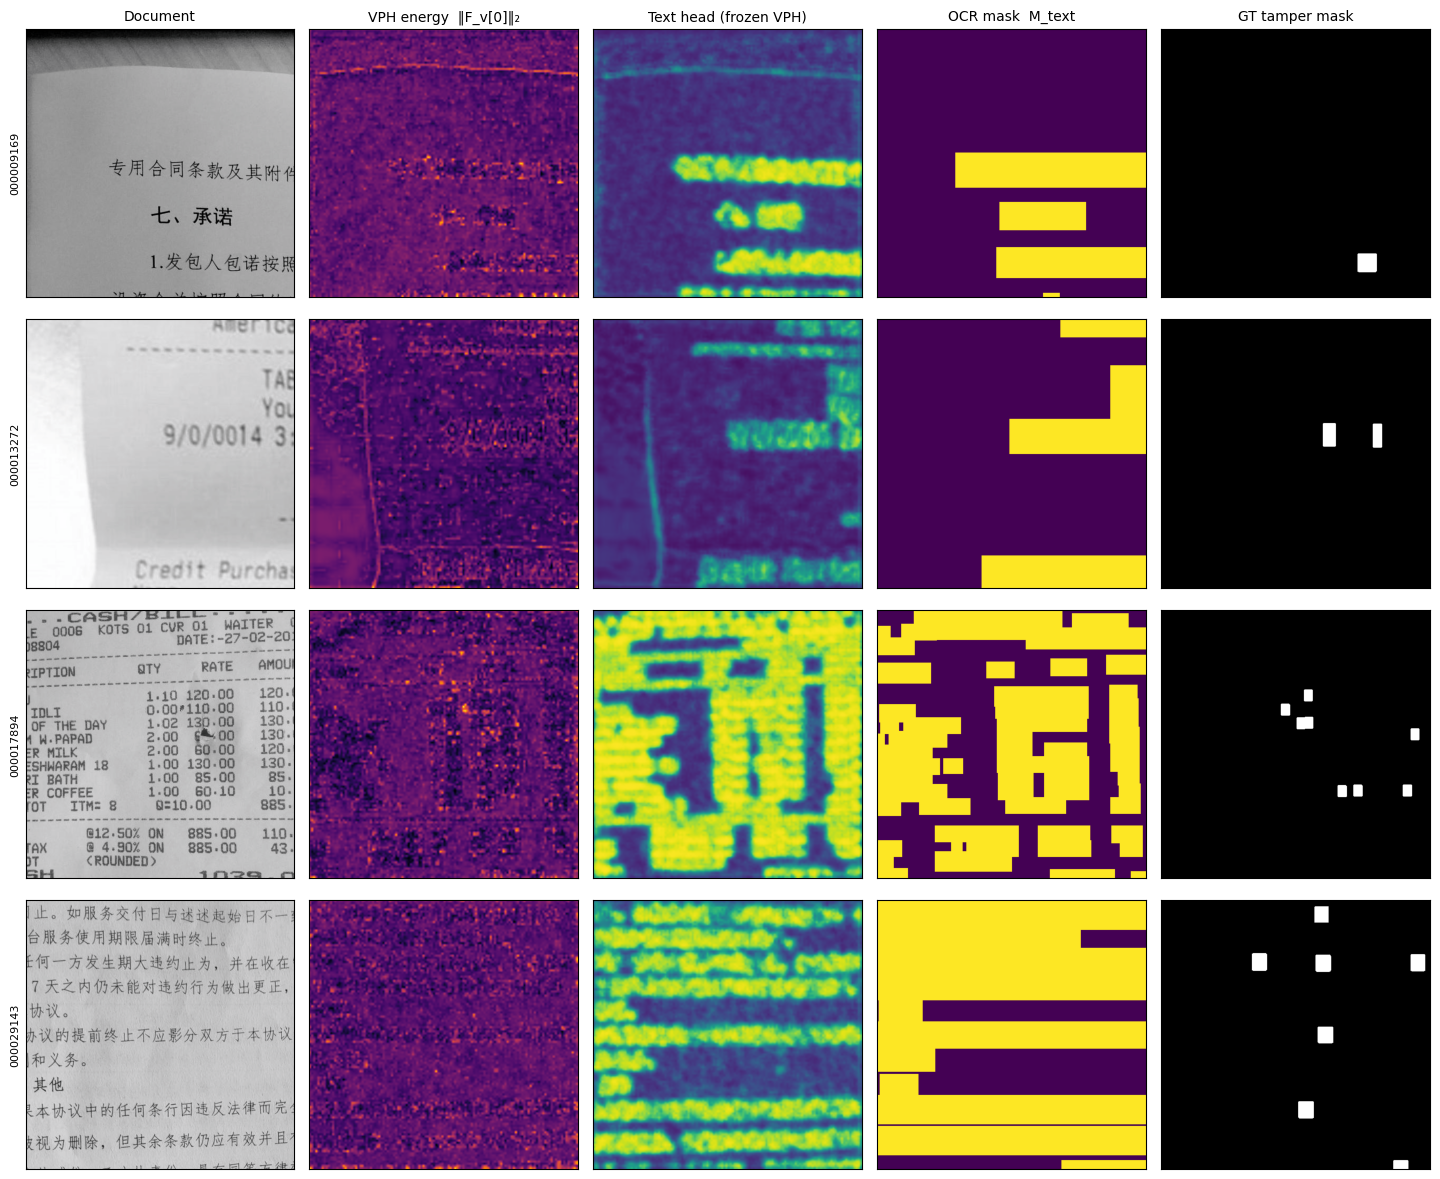

saved -> /content/drive/MyDrive/HLCV_samira/qualitative/fig_A_vph_vs_ocr.png


In [7]:
# --- Figure 1 ---
cols = [('Document', 'image'), ('VPH energy  ‖F_v[0]‖₂', 'energy')]
if ROWS[0]['thead'] is not None:
    cols.append(('Text head (frozen VPH)', 'thead'))
cols += [('OCR mask  M_text', 'ocr'), ('GT tamper mask', 'gt')]

fig, ax = plt.subplots(len(ROWS), len(cols), figsize=(2.9 * len(cols), 3.0 * len(ROWS)))
ax = np.atleast_2d(ax)
for r, row in enumerate(ROWS):
    for c, (title, key) in enumerate(cols):
        a = ax[r, c]; v = row[key]
        if key == 'image':
            a.imshow(v)
        elif key == 'gt':
            a.imshow(v, cmap='gray', vmin=0, vmax=1)
        elif key == 'energy':
            a.imshow(v, cmap='inferno', vmin=0, vmax=1)
        else:
            a.imshow(v, cmap='viridis', vmin=0, vmax=1)
        a.set_xticks([]); a.set_yticks([])
        if r == 0: a.set_title(title, fontsize=10)
    ax[r, 0].set_ylabel(row['sid'].split(':')[-1], fontsize=8)
plt.tight_layout()
plt.savefig(OUT / 'fig_A_vph_vs_ocr.png', dpi=150, bbox_inches='tight')
plt.show()
print('saved ->', OUT / 'fig_A_vph_vs_ocr.png')

In [8]:
# --- Supporting numbers for Figure 1: does the VPH readout agree with the OCR mask? ---
def iou(a, b):
    a, b = a.astype(bool), b.astype(bool)
    return (a & b).sum() / max((a | b).sum(), 1)

print(f"{'sample':<28}{'IoU(VPH_thr, OCR)':>20}{'IoU(head, OCR)':>18}{'corr(head,OCR)':>18}")
ious_e, ious_h, corrs = [], [], []
for row in ROWS:
    thr = np.percentile(row['energy'], CONFIG['VPH_PCTL'])
    ie = iou(row['energy'] > thr, row['ocr'] > 0.5); ious_e.append(ie)
    if row['thead'] is not None:
        ih = iou(row['thead'] > 0.5, row['ocr'] > 0.5); ious_h.append(ih)
        cc = np.corrcoef(row['thead'].ravel(), row['ocr'].ravel())[0, 1]; corrs.append(cc)
    else:
        ih, cc = float('nan'), float('nan')
    print(f"{row['sid'].split(':')[-1]:<28}{ie:>20.4f}{ih:>18.4f}{cc:>18.4f}")

print(f"\nmean IoU(VPH energy > p{CONFIG['VPH_PCTL']}, OCR mask) = {np.mean(ious_e):.4f}")
if ious_h:
    print(f"mean IoU(text head > 0.5, OCR mask)      = {np.mean(ious_h):.4f}")
    print(f"mean pixel correlation(text head, OCR)   = {np.mean(corrs):.4f}")
    print('\nThe text head is trained only on OCR pseudo-labels and reads FROZEN VPH features,')
    print('so this agreement is a measure of how much text information those features already carry.')

sample                         IoU(VPH_thr, OCR)    IoU(head, OCR)    corr(head,OCR)
000009169                                 0.1939            0.6736            0.8066
000013272                                 0.1890            0.4511            0.7644
000017894                                 0.1918            0.7392            0.6974
000029143                                 0.2762            0.7461            0.7003

mean IoU(VPH energy > p70, OCR mask) = 0.2127
mean IoU(text head > 0.5, OCR mask)      = 0.6525
mean pixel correlation(text head, OCR)   = 0.7422

The text head is trained only on OCR pseudo-labels and reads FROZEN VPH features,
so this agreement is a measure of how much text information those features already carry.


---
# 3. Figure 2 — and so the prior changes nothing

Loads the saved `+prior` arm from `final_results_colab.ipynb` and compares its prediction against
the frozen baseline on the same images. **The |Δ| column is the claim**: if the prior mattered, the
two predictions would differ somewhere.

In [9]:
# --- Baseline vs +prior predictions on the same images ---
arm_path = Path(CONFIG['FINAL_OUT']) / 'arms' / f"{CONFIG['PRIOR_ARM']}.pth"
have_arm = arm_path.exists()
print('prior arm:', arm_path if have_arm else 'NOT FOUND -- run final_results_colab cell 11 first')

@torch.no_grad()
def predict(m, idx, use_prior):
    s = test_ds[idx]
    batch = {k: (v.unsqueeze(0) if torch.is_tensor(v) else
                 (torch.from_numpy(v).unsqueeze(0) if isinstance(v, np.ndarray) else [v]))
             for k, v in s.items()}
    if use_prior:
        image = denorm(s['image'])
        det, _ = ocr_cache.get_or_compute(s['sample_id'], image, ocr_backend)
        mk = ocr_cache.mask_from_detections(det, image.shape)
        m.model.segmentation_head.text_mask = torch.from_numpy(mk[None, None]).float().to(DEVICE)
    with autocast(enabled=(DEVICE == 'cuda')):
        logits = forward_dtd(m, batch)
    logits = F.interpolate(logits.float(), size=(IMG, IMG), mode='bilinear', align_corners=False)
    return torch.softmax(logits, 1)[0, 1].cpu().numpy()

base_m = build_model(); base_m.eval()
P_base = [predict(base_m, p, False) for p in picks]
del base_m; torch.cuda.empty_cache()

if have_arm:
    prior_m = build_model(); wire_prior(prior_m)
    sd = torch.load(arm_path, map_location='cpu')['state_dict']
    prior_m.load_state_dict({k.replace('module.', ''): v for k, v in sd.items()}, strict=False)
    prior_m.eval()
    P_prior = [predict(prior_m, p, True) for p in picks]
    del prior_m; torch.cuda.empty_cache()
else:
    P_prior = None
print('predictions ready')

prior arm: /content/drive/MyDrive/HLCV_samira/final_seed42/arms/easyocr.pth


/tmp/ipykernel_670/1549114931.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE == 'cuda')):


predictions ready


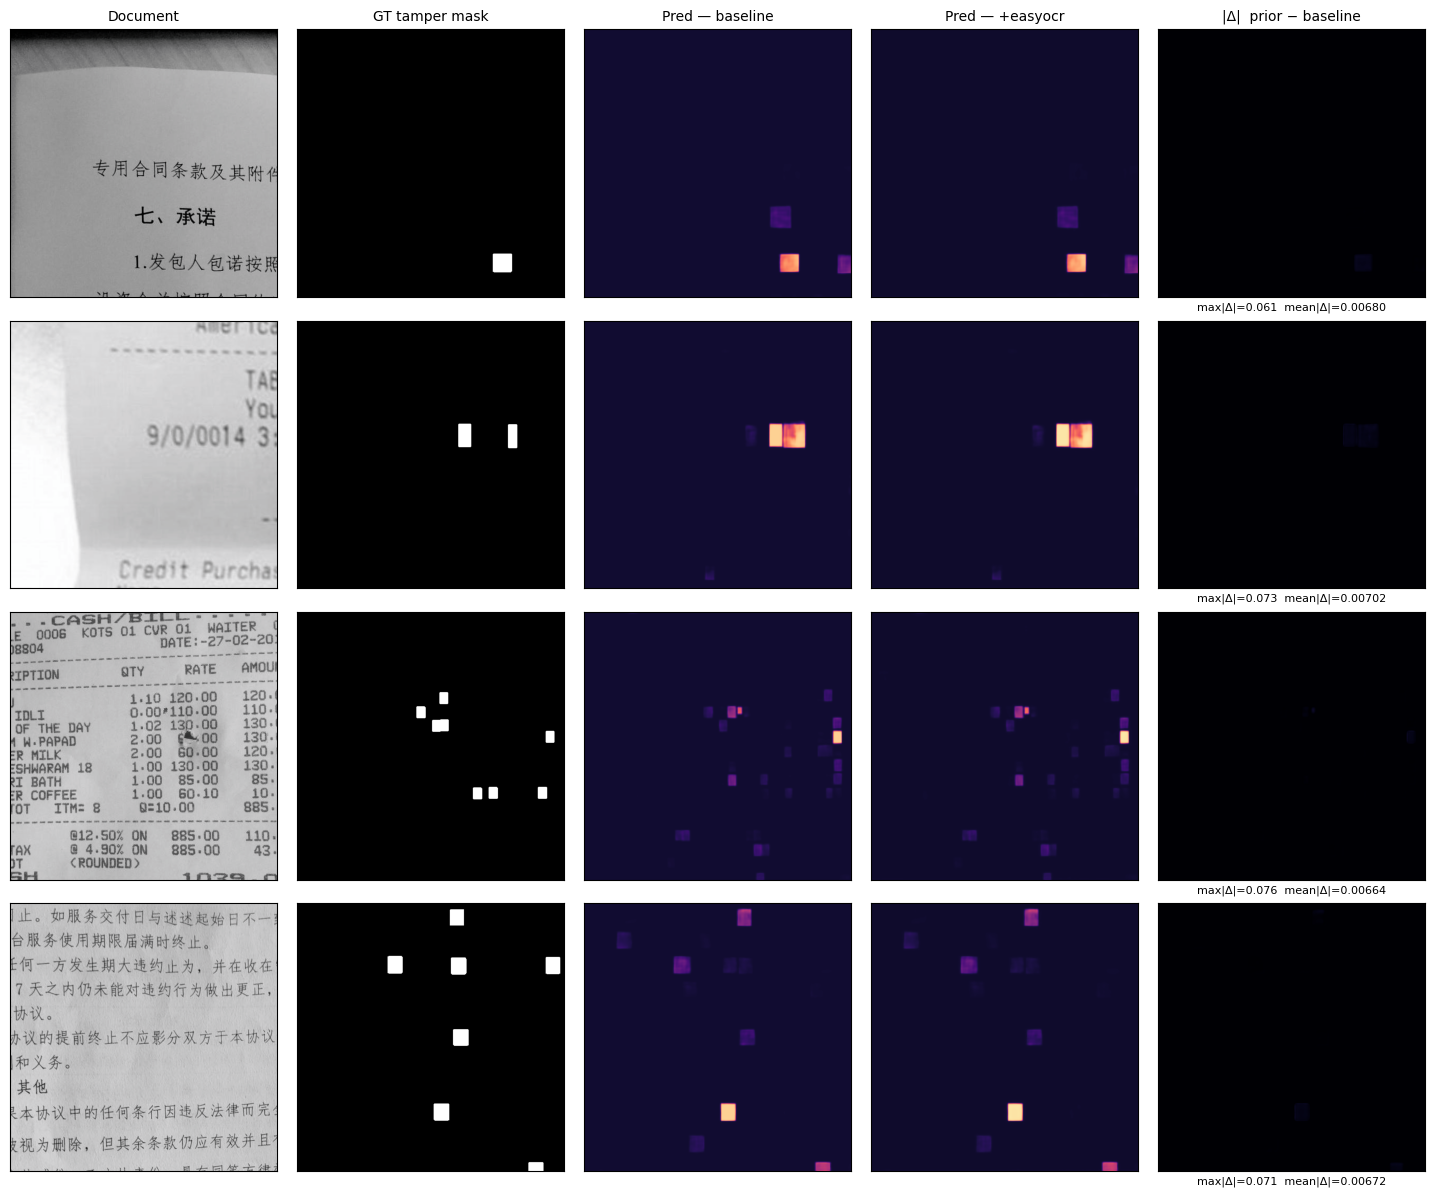

saved -> /content/drive/MyDrive/HLCV_samira/qualitative/fig_B_prior_delta.png


In [10]:
# --- Figure 2 ---
if P_prior is None:
    print('skipped: no saved +prior arm. Run final_results_colab.ipynb cell 11, then re-run.')
else:
    titles = ['Document', 'GT tamper mask', 'Pred — baseline', f"Pred — +{CONFIG['PRIOR_ARM']}",
              '|Δ|  prior − baseline']
    fig, ax = plt.subplots(len(ROWS), 5, figsize=(2.9 * 5, 3.0 * len(ROWS)))
    ax = np.atleast_2d(ax)
    for r, row in enumerate(ROWS):
        d = np.abs(P_prior[r] - P_base[r])
        panels = [row['image'], row['gt'], P_base[r], P_prior[r], d]
        for c, v in enumerate(panels):
            a = ax[r, c]
            if c == 0: a.imshow(v)
            elif c == 1: a.imshow(v, cmap='gray', vmin=0, vmax=1)
            elif c == 4: a.imshow(v, cmap='magma', vmin=0, vmax=1)     # SAME scale as the preds
            else: a.imshow(v, cmap='magma', vmin=0, vmax=1)
            a.set_xticks([]); a.set_yticks([])
            if r == 0: a.set_title(titles[c], fontsize=10)
        ax[r, 4].set_xlabel(f'max|Δ|={d.max():.3f}  mean|Δ|={d.mean():.5f}', fontsize=8)
    plt.tight_layout()
    plt.savefig(OUT / 'fig_B_prior_delta.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('saved ->', OUT / 'fig_B_prior_delta.png')

In [11]:
# --- Supporting numbers for Figure 2, over the WHOLE test split (not just the plotted rows) ---
if P_prior is None:
    print('skipped')
else:
    base_m = build_model(); base_m.eval()
    prior_m = build_model(); wire_prior(prior_m)
    sd = torch.load(arm_path, map_location='cpu')['state_dict']
    prior_m.load_state_dict({k.replace('module.', ''): v for k, v in sd.items()}, strict=False)
    prior_m.eval()

    dmax, dmean, flips, npx = [], [], 0, 0
    for i in range(len(test_ds)):
        pb, pp = predict(base_m, i, False), predict(prior_m, i, True)
        d = np.abs(pp - pb)
        dmax.append(d.max()); dmean.append(d.mean())
        flips += int(((pb > 0.5) != (pp > 0.5)).sum()); npx += d.size
    del base_m, prior_m; torch.cuda.empty_cache()

    print(f'over all {len(test_ds)} test images:')
    print(f'  mean |Δ| per pixel          : {np.mean(dmean):.6f}')
    print(f'  mean of per-image max |Δ|   : {np.mean(dmax):.4f}')
    print(f'  pixels whose LABEL flipped  : {flips:,} / {npx:,}  ({100*flips/npx:.4f}%)')
    print('\nThis is the quantitative form of the |Δ| column: the fraction of pixels where adding')
    print('the OCR prior changed the binary decision at threshold 0.5.')

/tmp/ipykernel_670/1549114931.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE == 'cuda')):


over all 200 test images:
  mean |Δ| per pixel          : 0.007058
  mean of per-image max |Δ|   : 0.0740
  pixels whose LABEL flipped  : 16,655 / 52,428,800  (0.0318%)

This is the quantitative form of the |Δ| column: the fraction of pixels where adding
the OCR prior changed the binary decision at threshold 0.5.
